In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [53]:
## Movies Analysis
movies = pd.read_csv('movies_clean.csv')
print("Movies.csv columns:: ",movies['movieId'].unique().size)
print("Number of Unique Books:: ",movies['movieId'].unique().size)
movies.head()

Movies.csv columns::  9742
Number of Unique Books::  9742


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [54]:
## Ratings Analysis
ratings = pd.read_csv('ratings_clean.csv')
print("Number of rated movies",ratings['movieId'].unique().size)
print("Number of Ratings::",ratings.shape)
print("Number of unique users:: ",ratings['userId'].unique().size)
ratings.head()

Number of rated movies 9724
Number of Ratings:: (100836, 4)
Number of unique users::  610


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [55]:
print("Most popular movies:: ",ratings['movieId'].value_counts().head())

Most popular movies::  movieId
356     329
318     317
296     307
593     279
2571    278
Name: count, dtype: int64


In [56]:
ratings_movies = pd.read_csv('ratings_with_movies.csv')
print("number of movies :: ",ratings_movies['movieId'].unique().size)
ratings_movies.head()

number of movies ::  9724


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [57]:
pivot = ratings_movies.pivot_table(index=['userId'],columns=['movieId'],values='rating').fillna(0)
pivot.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [58]:
user_list = list(pivot.index)
movie_list = list(pivot.columns)
print("Number of users:: ",len(user_list))
print("Number of movies:: ",len(movie_list))

Number of users::  610
Number of movies::  9724


In [59]:
num_non_zero_values = (pivot==0).sum().sum()
print("Number of zero values:: ",num_non_zero_values)
print("Number of non-zero values:: ",pivot.size-num_non_zero_values)
# !pip install scipy
# from scipy import coo_matrix

# R = coo_matrix(pivot.values)

Number of zero values::  5830804
Number of non-zero values::  100836


In [60]:
import sys
import pandas as pd

# Get the size of the DataFrame object itself
df_object_size = sys.getsizeof(pivot)
print(f"DataFrame object size: {df_object_size / (1024**2):.2f} MB")

# Get the total memory usage including data types (more comprehensive for DataFrames)
total_df_memory_usage = pivot.memory_usage(deep=True).sum()
print(f"Total DataFrame memory usage (including data): {total_df_memory_usage / (1024**2):.2f} MB")

DataFrame object size: 45.26 MB
Total DataFrame memory usage (including data): 45.26 MB


In [61]:
import sys
from scipy.sparse import coo_matrix
import pandas as pd

R = coo_matrix(pivot.values)
size_bytes = sys.getsizeof(R.data) + sys.getsizeof(R.row) + sys.getsizeof(R.col)
print(f"COO Matrix Size: {size_bytes / (1024**2):.2f} MB")


COO Matrix Size: 1.54 MB


In [62]:
from scipy.sparse.linalg import svds

def SVD(R, k):
  # 1. Get raw SVD
    P, sigma, Q = svds(R, k=k)

    # 2. BALANCE THE FACTORS: Distribute the singular values evenly
    # This prevents Q from having massive values that explode the gradients
    sqrt_sigma = np.diag(np.sqrt(sigma))

    P_factors = P @ sqrt_sigma
    Q_factors = sqrt_sigma @ Q

    return P_factors, Q_factors


In [63]:
print(R)

<COOrdinate sparse matrix of dtype 'float64'
	with 100836 stored elements and shape (610, 9724)>
  Coords	Values
  (0, 0)	4.0
  (0, 2)	4.0
  (0, 5)	4.0
  (0, 43)	5.0
  (0, 46)	5.0
  (0, 62)	3.0
  (0, 89)	5.0
  (0, 97)	4.0
  (0, 124)	5.0
  (0, 130)	5.0
  (0, 136)	5.0
  (0, 184)	5.0
  (0, 190)	3.0
  (0, 197)	5.0
  (0, 201)	4.0
  (0, 224)	5.0
  (0, 257)	3.0
  (0, 275)	3.0
  (0, 291)	5.0
  (0, 307)	4.0
  (0, 314)	4.0
  (0, 320)	5.0
  (0, 325)	4.0
  (0, 367)	3.0
  (0, 384)	4.0
  :	:
  (609, 9238)	5.0
  (609, 9246)	4.5
  (609, 9256)	4.0
  (609, 9268)	5.0
  (609, 9274)	3.5
  (609, 9279)	3.5
  (609, 9282)	3.0
  (609, 9288)	3.0
  (609, 9304)	3.0
  (609, 9307)	2.5
  (609, 9312)	4.5
  (609, 9317)	3.0
  (609, 9324)	3.0
  (609, 9339)	4.0
  (609, 9341)	4.0
  (609, 9348)	3.5
  (609, 9371)	3.5
  (609, 9372)	3.5
  (609, 9374)	5.0
  (609, 9415)	4.0
  (609, 9416)	4.0
  (609, 9443)	5.0
  (609, 9444)	5.0
  (609, 9445)	5.0
  (609, 9485)	3.0


In [64]:
R.data

array([4., 4., 4., ..., 5., 5., 3.])

In [65]:
R.row

array([  0,   0,   0, ..., 609, 609, 609], dtype=int32)

In [66]:
R.col

array([   0,    2,    5, ..., 9444, 9445, 9485], dtype=int32)

In [67]:
from numpy.linalg import norm
def error(R,P,Q,lamda=0.02):
  ratings = R.data
  rows = R.row
  cols = R.col
  err = 0
  for ui in range(len(ratings)):
    actual_rating = ratings[ui]
    u = rows[ui]
    i = cols[ui]
    if actual_rating > 0 :
          err += np.pow(actual_rating - np.dot(P[u,:],Q[:,i]),2) + lamda * np.pow(norm(P[u,:]),2) + np.pow(norm(Q[:,i]),2)
  return err

In [68]:
P_factors, Q_factors = SVD(R,3)
error(R, P_factors, Q_factors)

np.float64(907456.5043911495)

In [69]:
rmse = np.sqrt(error(R, P_factors, Q_factors)/len(R.data))
print(f"RMSE:{rmse}")

RMSE:2.9998884378861614


In [70]:
import numpy as np

import numpy as np

def SGD_vectorized_fixed(R, P, Q, lamda=0.01, steps=15, lr=2e-6):
    rows = R.row
    cols = R.col
    ratings = R.data
    Q_T = Q.T.copy()

    for step in range(steps):
        # 1. Predictions & Error
        predictions = np.sum(P[rows, :] * Q_T[cols, :], axis=1)
        errors = ratings - predictions

        # 2. RMSE
        rmse = np.sqrt(np.mean(errors**2))
        print(f"Step: {step:2d} | RMSE: {rmse:.4f}")

        # 3. Gradient Updates
        # Calculate gradient contributions from the errors ONLY
        p_grad_error = 2 * errors[:, np.newaxis] * Q_T[cols, :]
        q_grad_error = 2 * errors[:, np.newaxis] * P[rows, :]

        # Accumulate ONLY the error-based updates
        np.add.at(P, rows, lr * p_grad_error)
        np.add.at(Q_T, cols, lr * q_grad_error)

        # Apply L2 Regularization ONCE per factor per step, NOT once per rating!
        P -= 2 * lr * lamda * P
        Q_T -= 2 * lr * lamda * Q_T

    return P, Q_T.T


In [71]:
# 1. Re-initialize factors to wipe any NaNs
P_factors, Q_factors = SVD(R, 3)

# 2. Run with smaller learning rate (e.g., 1e-5 or 1e-4)
P, Q = SGD_vectorized_fixed(R, P_factors, Q_factors, lr=0.00005, lamda=0.01, steps=15)

Step:  0 | RMSE: 2.8225
Step:  1 | RMSE: 2.7938
Step:  2 | RMSE: 2.7653
Step:  3 | RMSE: 2.7372
Step:  4 | RMSE: 2.7095
Step:  5 | RMSE: 2.6821
Step:  6 | RMSE: 2.6552
Step:  7 | RMSE: 2.6288
Step:  8 | RMSE: 2.6028
Step:  9 | RMSE: 2.5774
Step: 10 | RMSE: 2.5524
Step: 11 | RMSE: 2.5279
Step: 12 | RMSE: 2.5040
Step: 13 | RMSE: 2.4805
Step: 14 | RMSE: 2.4575


Epoch  0 | Loss: 642411 | Train RMSE: 2.8219 | Val RMSE: 2.8249
Epoch  1 | Loss: 641986 | Train RMSE: 2.8210 | Val RMSE: 2.8240
Epoch  2 | Loss: 641562 | Train RMSE: 2.8201 | Val RMSE: 2.8232
Epoch  3 | Loss: 641138 | Train RMSE: 2.8192 | Val RMSE: 2.8223
Epoch  4 | Loss: 640714 | Train RMSE: 2.8182 | Val RMSE: 2.8214
Epoch  5 | Loss: 640291 | Train RMSE: 2.8173 | Val RMSE: 2.8206
Epoch  6 | Loss: 639867 | Train RMSE: 2.8164 | Val RMSE: 2.8197
Epoch  7 | Loss: 639444 | Train RMSE: 2.8154 | Val RMSE: 2.8188
Epoch  8 | Loss: 639022 | Train RMSE: 2.8145 | Val RMSE: 2.8180
Epoch  9 | Loss: 638599 | Train RMSE: 2.8136 | Val RMSE: 2.8171


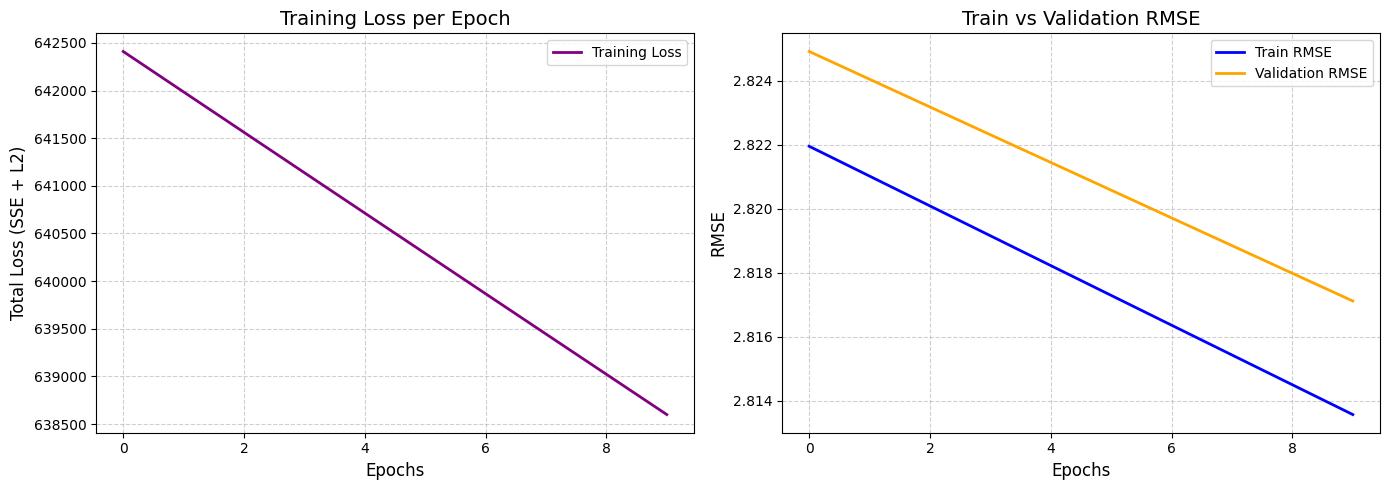

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.sparse import coo_matrix


# We split the non-zero ratings: 80% for training, 20% for validation
train_data, val_data, train_row, val_row, train_col, val_col = train_test_split(
    R.data, R.row, R.col, test_size=0.2, random_state=42
)

R_train = coo_matrix((train_data, (train_row, train_col)), shape=R.shape)
R_val = coo_matrix((val_data, (val_row, val_col)), shape=R.shape)


def SGD_with_history(R_train, R_val, P, Q, lamda=0.01, steps=25, lr=2e-6):
    # Train targets
    train_rows, train_cols, train_ratings = R_train.row, R_train.col, R_train.data
    # Validation targets
    val_rows, val_cols, val_ratings = R_val.row, R_val.col, R_val.data

    Q_T = Q.T.copy()

    # Dictionary to store metrics for plotting
    history = {'train_rmse': [], 'val_rmse': [], 'loss': []}

    for step in range(steps):
        train_preds = np.sum(P[train_rows, :] * Q_T[train_cols, :], axis=1)
        train_errors = train_ratings - train_preds
        train_rmse = np.sqrt(np.mean(train_errors**2))

        val_preds = np.sum(P[val_rows, :] * Q_T[val_cols, :], axis=1)
        val_errors = val_ratings - val_preds
        val_rmse = np.sqrt(np.mean(val_errors**2))

        
        reg_loss = lamda * (np.sum(P**2) + np.sum(Q_T**2))
        total_loss = np.sum(train_errors**2) + reg_loss

 
        history['train_rmse'].append(train_rmse)
        history['val_rmse'].append(val_rmse)
        history['loss'].append(total_loss)

        print(f"Epoch {step:2d} | Loss: {total_loss:.0f} | Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")

        
        p_grad_error = 2 * train_errors[:, np.newaxis] * Q_T[train_cols, :]
        q_grad_error = 2 * train_errors[:, np.newaxis] * P[train_rows, :]

        np.add.at(P, train_rows, lr * p_grad_error)
        np.add.at(Q_T, train_cols, lr * q_grad_error)

        P -= 2 * lr * lamda * P
        Q_T -= 2 * lr * lamda * Q_T

    return P, Q_T.T, history

#  EXECUTE TRAINING & PLOT


P_init, Q_init = SVD(R, k=3)
P_final, Q_final, history = SGD_with_history(R_train, R_val, P_init, Q_init, lr=2e-6, lamda=0.01, steps=10)

# Create the plots
plt.figure(figsize=(14, 5))

# Plot 1: Training Loss
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss', color='purple', linewidth=2)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Total Loss (SSE + L2)', fontsize=12)
plt.title('Training Loss per Epoch', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Plot 2: RMSE (Train vs Val)
plt.subplot(1, 2, 2)
plt.plot(history['train_rmse'], label='Train RMSE', color='blue', linewidth=2)
plt.plot(history['val_rmse'], label='Validation RMSE', color='orange', linewidth=2)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('Train vs Validation RMSE', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()


 Training Model -> k: 10 | Regularization (λ): 0.001
Epoch  0 | Loss: 524334 | Train RMSE: 2.5495 | Val RMSE: 2.5508
Epoch  1 | Loss: 524009 | Train RMSE: 2.5487 | Val RMSE: 2.5501
Epoch  2 | Loss: 523685 | Train RMSE: 2.5479 | Val RMSE: 2.5493
Epoch  3 | Loss: 523360 | Train RMSE: 2.5471 | Val RMSE: 2.5486
Epoch  4 | Loss: 523036 | Train RMSE: 2.5463 | Val RMSE: 2.5479
Epoch  5 | Loss: 522712 | Train RMSE: 2.5455 | Val RMSE: 2.5472
Epoch  6 | Loss: 522388 | Train RMSE: 2.5447 | Val RMSE: 2.5465
Epoch  7 | Loss: 522065 | Train RMSE: 2.5440 | Val RMSE: 2.5458
Epoch  8 | Loss: 521742 | Train RMSE: 2.5432 | Val RMSE: 2.5451
Epoch  9 | Loss: 521419 | Train RMSE: 2.5424 | Val RMSE: 2.5444

 Training Model -> k: 10 | Regularization (λ): 0.01
Epoch  0 | Loss: 524369 | Train RMSE: 2.5495 | Val RMSE: 2.5508
Epoch  1 | Loss: 524044 | Train RMSE: 2.5487 | Val RMSE: 2.5501
Epoch  2 | Loss: 523719 | Train RMSE: 2.5479 | Val RMSE: 2.5493
Epoch  3 | Loss: 523395 | Train RMSE: 2.5471 | Val RMSE: 2.54

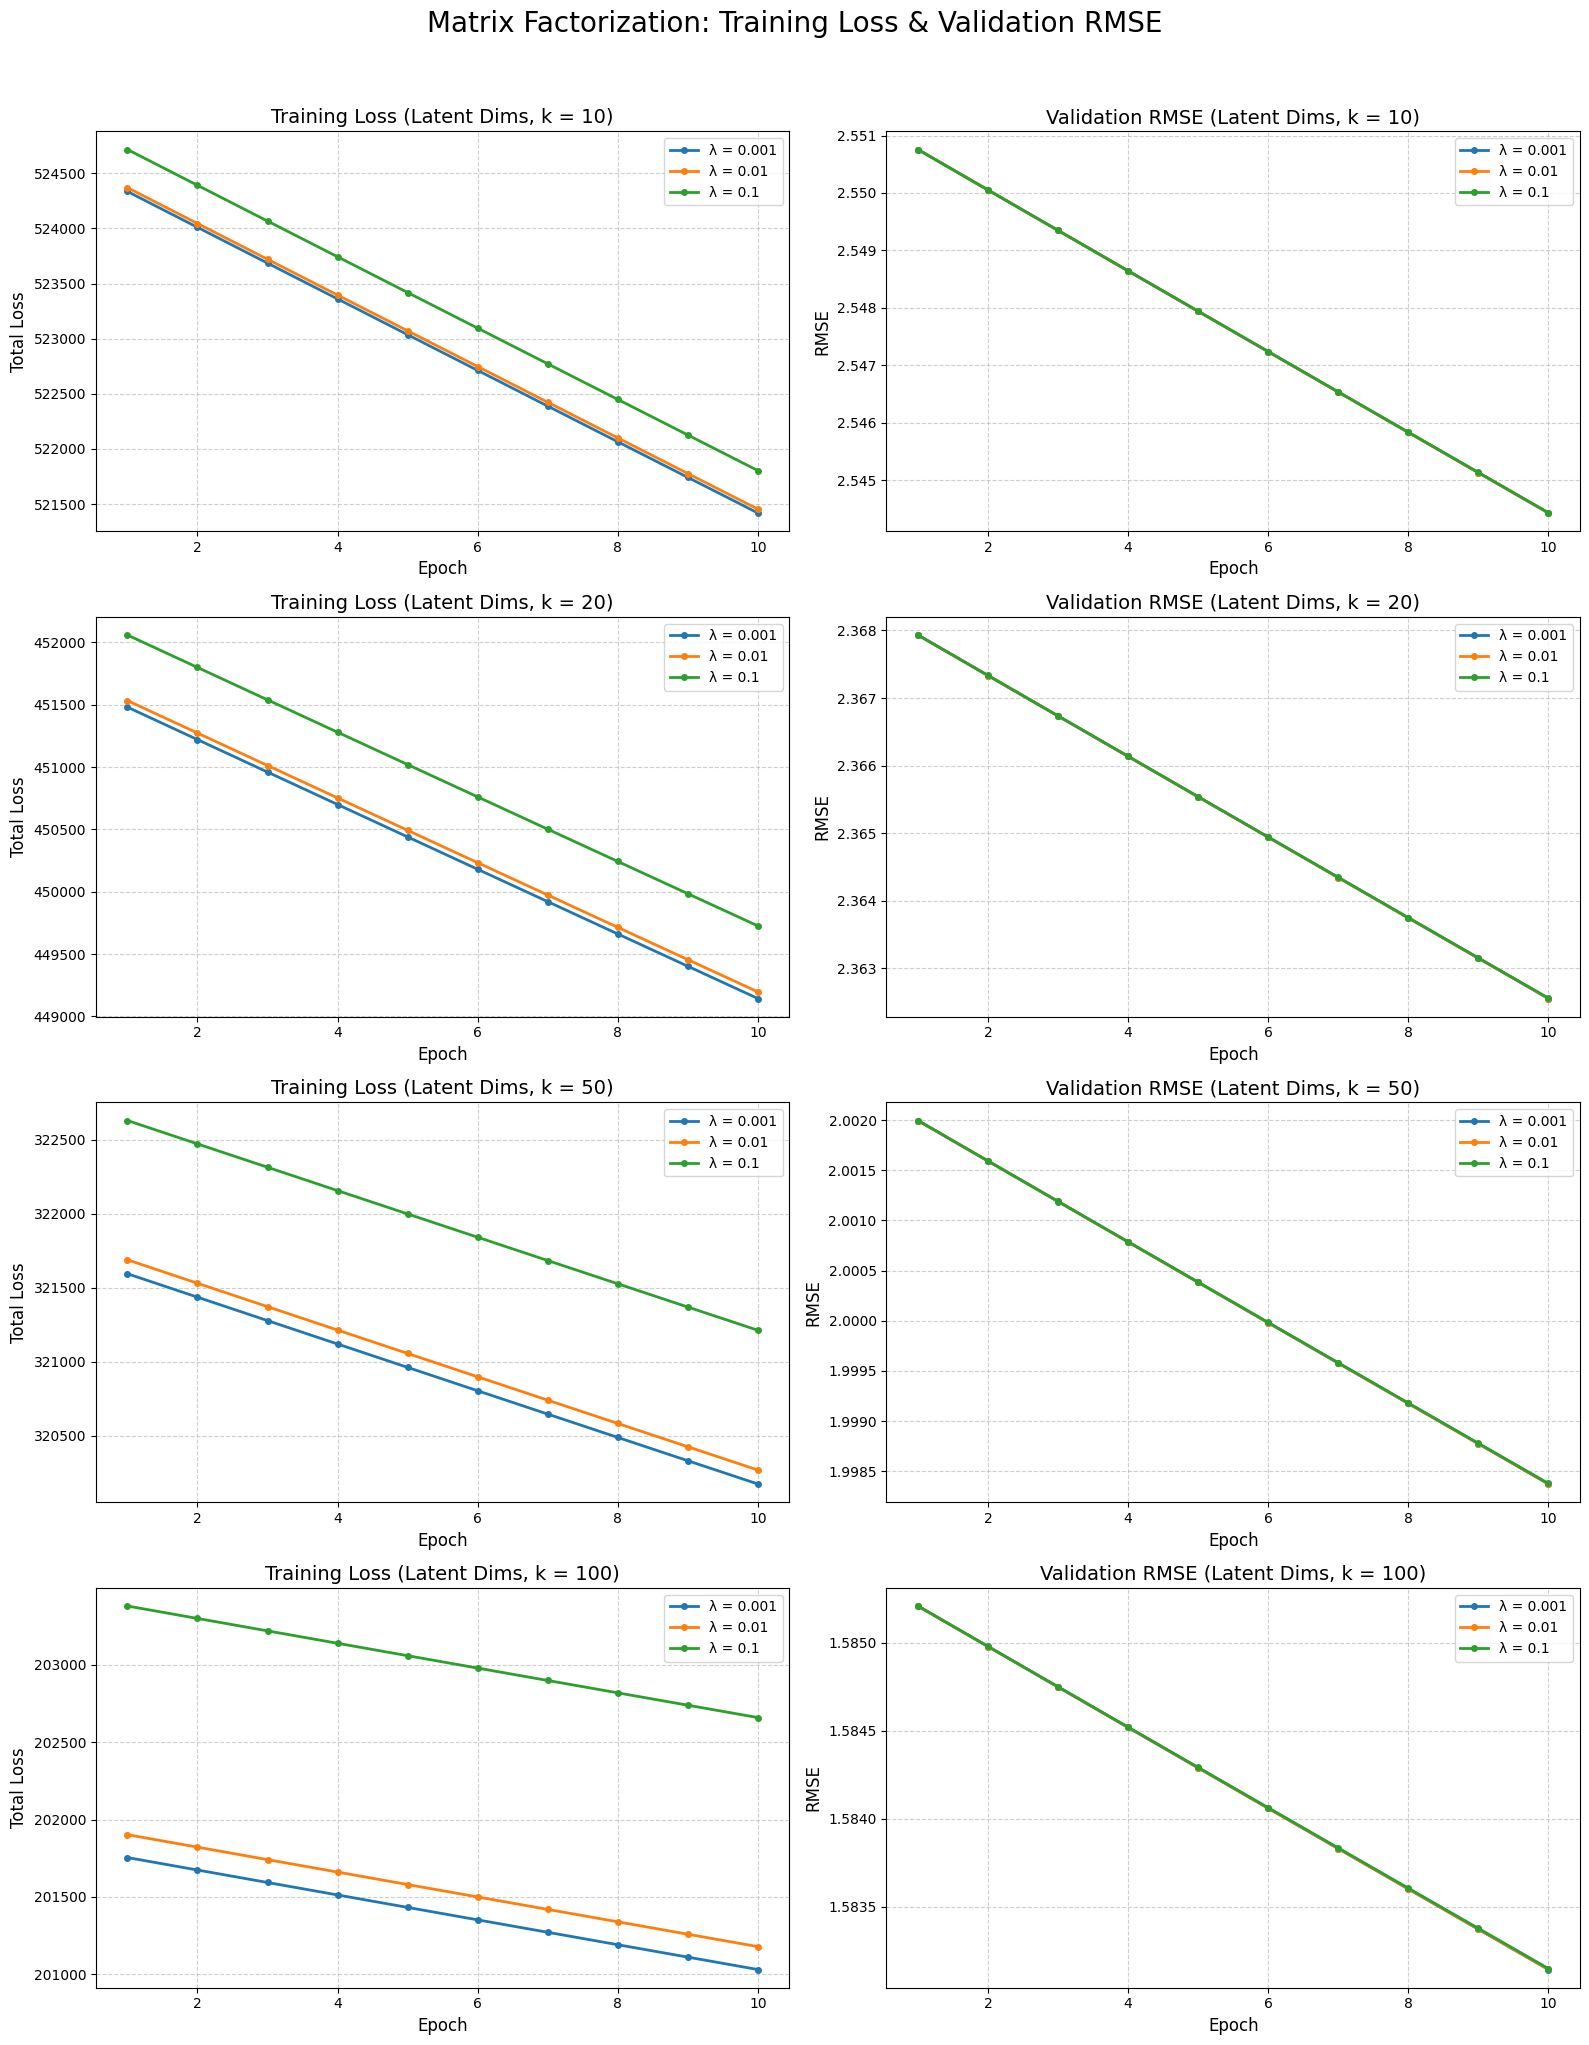

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import svds


k_values = [10, 20, 50, 100]
lamda_values = [0.001, 0.01, 0.1]
EPOCHS = 10        
LEARNING_RATE = 2e-6 \

# Dictionary to store the history of every run
experiment_results = {}

# ==========================================
# 2. RUN EXPERIMENTS
# ==========================================
for k in k_values:
    for lamda in lamda_values:
        print(f"\n==============================================")
        print(f" Training Model -> k: {k} | Regularization (λ): {lamda}")
        print(f"==============================================")

        P_init, Q_init = SVD(R, k=k)


        P_final, Q_final, history = SGD_with_history(
            R_train, R_val, P_init, Q_init,
            lamda=lamda, steps=EPOCHS, lr=LEARNING_RATE
        )

        # Store results for plotting
        experiment_results[(k, lamda)] = history



# PLOT THE RESULTS
# Create a figure with len(k_values) rows and 2 columns
fig, axes = plt.subplots(nrows=len(k_values), ncols=2, figsize=(16, 5 * len(k_values)))
fig.suptitle('Matrix Factorization: Training Loss & Validation RMSE', fontsize=20, y=1.02)

for i, k in enumerate(k_values):
    ax_loss = axes[i, 0]
    ax_rmse = axes[i, 1]

    for lamda in lamda_values:
        history = experiment_results[(k, lamda)]
        epochs_range = range(1, EPOCHS + 1)

        # Plot Training Loss
        ax_loss.plot(epochs_range, history['loss'], label=f'λ = {lamda}', linewidth=2, marker='o', markersize=4)

        # Plot Validation RMSE
        ax_rmse.plot(epochs_range, history['val_rmse'], label=f'λ = {lamda}', linewidth=2, marker='o', markersize=4)

    # Formatting Loss Subplot
    ax_loss.set_title(f'Training Loss (Latent Dims, k = {k})', fontsize=14)
    ax_loss.set_xlabel('Epoch', fontsize=12)
    ax_loss.set_ylabel('Total Loss', fontsize=12)
    ax_loss.legend()
    ax_loss.grid(True, linestyle='--', alpha=0.6)

    # Formatting RMSE Subplot
    ax_rmse.set_title(f'Validation RMSE (Latent Dims, k = {k})', fontsize=14)
    ax_rmse.set_xlabel('Epoch', fontsize=12)
    ax_rmse.set_ylabel('RMSE', fontsize=12)
    ax_rmse.legend()
    ax_rmse.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
best_val_rmse = float('inf')
best_config = None

for (k, lamda), history in experiment_results.items():
    min_config_rmse = min(history['val_rmse'])

    if min_config_rmse < best_val_rmse:
        best_val_rmse = min_config_rmse
        best_config = (k, lamda)

# Report the results
print("----BEST CONFIGURATION FOUND----")
print("-" * 30)
print(f"Latent Dimensions (k) : {best_config[0]}")
print(f"Regularization (λ)    : {best_config[1]}")
print(f"Best Validation RMSE  : {best_val_rmse:.4f}")

----BEST CONFIGURATION FOUND----
------------------------------
Latent Dimensions (k) : 100
Regularization (λ)    : 0.001
Best Validation RMSE  : 1.5831


In [87]:
import plotly.express as px

# Create the interactive scatter plot
fig = px.scatter(
    plot_df,
    x='x',
    y='y',
    color='primary_genre',         # Colors the dots by genre
    hover_name='title',            # Shows the movie title in bold when you hover!
    hover_data={'primary_genre': True, 'x': False, 'y': False}, # Shows the genre in the tooltip
    title='Interactive PCA of Movie Latent Vectors',
    labels={
        'x': 'Principal Component 1 (Popularity/Overall Rating)',
        'y': 'Principal Component 2 (Genre Separation)'
    },
    opacity=0.7                    # Makes the dots slightly transparent so you can see overlaps
)

# Adjust the size and layout to make it look clean
fig.update_layout(
    width=1000,
    height=700,
    legend_title_text='Click a genre to filter!',
    template='plotly_white'        # Gives it a clean white background
)

# Display the interactive plot
fig.show()

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def get_similar_movies(target_title, Q_matrix, top_n=5):
    # Find the movieId for the target title
    target_match = movies[movies['title'].str.contains(target_title, case=False, na=False,regex=False)]
    if target_match.empty:
        return "Movie not found!"
    target_id = target_match.iloc[0]['movieId']
    genre = movies[movies['movieId'] == target_id]['genres'].values[0]
    print(genre)
    # Find the matrix index for this movieId
    if target_id not in pivot.columns:
        return "Movie not in training set!"
    target_idx = list(pivot.columns).index(target_id)

    # Compute Cosine Similarity between this movie and ALL movies
    target_vector = Q_matrix[target_idx].reshape(1, -1)
    similarities = cosine_similarity(target_vector, Q_matrix).flatten()

  
    # argsort sorts ascending, so we take the end of the array and reverse it
    similar_indices = similarities.argsort()[-(top_n+1):][::-1]

    # Remove the target movie itself from the list
    similar_indices = [i for i in similar_indices if i != target_idx][:top_n]

    results = []
    for idx in similar_indices:
        sim_score = similarities[idx]
        m_id = pivot.columns[idx]
        title = movies[movies['movieId'] == m_id]['title'].values[0]
        genre = movies[movies['movieId'] == m_id]['genres'].values[0]
        results.append((title,genre, sim_score))

    return pd.DataFrame(results, columns=['Title','Genre', 'Cosine Similarity'])

print(f"Movies similar to 'Toy Story (1995)':")
get_similar_movies("Toy Story (1995)", Q_final, top_n=5)

Movies similar to 'Toy Story (1995)':
Adventure|Animation|Children|Comedy|Fantasy


,Title,Genre,Cosine Similarity
0,Powder (1995),Drama|Sci-Fi,0.000096
1,Mortal Kombat (1995),Action|Adventure|Fantasy,0.000094
2,From Dusk Till Dawn (1996),Action|Comedy|Horror|Thriller,0.000071
3,"Indian in the Cupboard, The (1995)",Adventure|Children|Fantasy,0.000070
4,Heat (1995),Action|Crime|Thriller,0.000069


In [ ]:
def recommend_for_user(user_matrix_idx, P_matrix, Q_matrix, pivot_df, top_n=10):
    user_id = pivot_df.index[user_matrix_idx]

    # Predict ratings for ALL movies for this user
    user_vector = P_matrix[user_matrix_idx]
    predictions = np.dot(user_vector, Q_matrix)

    # Get the movies the user has ALREADY rated (to exclude them)
    user_history = pivot_df.iloc[user_matrix_idx]
    already_rated_indices = np.where(user_history > 0)[0]

    # Set predictions for already rated movies to negative infinity
    predictions[already_rated_indices] = -np.inf

    #  Get the indices of the highest predicted scores
    top_indices = predictions.argsort()[-top_n:][::-1]

    #  Map indices back to titles
    recs = []
    for idx in top_indices:
        m_id = pivot_df.columns[idx]
        title = movies[movies['movieId'] == m_id]['title'].values[0]
        recs.append(title)

    return pd.DataFrame({f'User {user_id} Recs': recs}, index=range(1, top_n+1))

# Generate and display side-by-side for the first 3 users (indices 0, 1, 2)
user1_recs = recommend_for_user(0, P_final, Q_final, pivot)
user2_recs = recommend_for_user(1, P_final, Q_final, pivot)
user3_recs = recommend_for_user(2, P_final, Q_final, pivot)

display(pd.concat([user1_recs, user2_recs, user3_recs], axis=1))

,User 1 Recs,User 2 Recs,User 3 Recs
1,Bill & Ted's Excellent Adventure (1989),Fight Club (1999),Alien (1979)
2,Chasing Amy (1997),"Social Network, The (2010)",Aliens (1986)
3,Dr. Strangelove or: How I Learned to Stop Worr...,"Matrix, The (1999)","Exorcist, The (1973)"
4,"Firm, The (1993)","Prestige, The (2006)",Superman II (1980)
5,Aliens (1986),"Lord of the Rings: The Fellowship of the Ring,...",Predator (1987)
6,Ice Age (2002),"Hangover, The (2009)",Planet of the Apes (1968)
7,Casino (1995),The Martian (2015),Star Trek II: The Wrath of Khan (1982)
8,Free Willy (1993),"Truman Show, The (1998)",Mad Max (1979)
9,Rain Man (1988),Deadpool (2016),2001: A Space Odyssey (1968)
10,"Bug's Life, A (1998)","Avengers, The (2012)",RoboCop (1987)


In [ ]:
from sklearn.model_selection import train_test_split
from scipy.sparse import coo_matrix
import numpy as np

#  CREATE THE 80/10/10 SPLITS SAFELY
train_data, temp_data, train_row, temp_row, train_col, temp_col = train_test_split(
    R.data, R.row, R.col, test_size=0.20, random_state=42
)
val_data, test_data, val_row, test_row, val_col, test_col = train_test_split(
    temp_data, temp_row, temp_col, test_size=0.50, random_state=42
)

R_train = coo_matrix((train_data, (train_row, train_col)), shape=R.shape)
R_val   = coo_matrix((val_data, (val_row, val_col)), shape=R.shape)
R_test  = coo_matrix((test_data, (test_row, test_col)), shape=R.shape)

#  DEFINE THE FIXED EVALUATION FUNCTION
def evaluate_model_global_fixed(P_matrix, Q_matrix, train_matrix, test_matrix, top_n=10, threshold=4.0):
    val_rows, val_cols, val_data = test_matrix.row, test_matrix.col, test_matrix.data

    user_relevant_items = {}
    for user_idx, item_idx, rating in zip(val_rows, val_cols, val_data):
        if rating >= threshold:
            if user_idx not in user_relevant_items:
                user_relevant_items[user_idx] = set()
            user_relevant_items[user_idx].add(item_idx)

    all_predictions = np.dot(P_matrix, Q_matrix)

    # MASK ONLY THE TRAINING SET
    train_mask = (train_matrix.toarray() > 0)
    all_predictions[train_mask] = -np.inf

    total_precision, total_recall, users_evaluated = 0, 0, 0

    for user_idx in range(P_matrix.shape[0]):
        if user_idx not in user_relevant_items:
            continue

        relevant_items = user_relevant_items[user_idx]
        top_indices = all_predictions[user_idx].argsort()[-top_n:][::-1]

        hits = set(top_indices).intersection(relevant_items)

        total_precision += len(hits) / top_n
        total_recall += len(hits) / len(relevant_items)
        users_evaluated += 1

    avg_precision = total_precision / users_evaluated
    avg_recall = total_recall / users_evaluated

    print(f"Evaluated on {users_evaluated} users")
    print(f"Average Precision@{top_n} : {avg_precision:.4f}")
    print(f"Average Recall@{top_n}    : {avg_recall:.4f}")
    return avg_precision, avg_recall

# RUN THE FINAL EXAM ON UNSEEN TEST SET
print("\n" + "="*50)
print(" FINAL SYSTEMATIC EVALUATION (UNSEEN TEST SET) ")
print("="*50)

print("\n--- Model: Matrix Factorization ---")
# Using the P_final_test and Q_final_test you just trained in the previous cell!
mf_test_precision, mf_test_recall = evaluate_model_global_fixed(
    P_final_test, Q_final_test, R_train, R_test, top_n=10, threshold=4.0
)

print("\n--- Model: Global Popularity Baseline ---")
movie_popularity = np.array(pivot.sum(axis=0))
popularity_predictions = np.tile(movie_popularity, (P_final_test.shape[0], 1))

pop_test_precision, pop_test_recall = evaluate_model_global_fixed(
    np.eye(P_final_test.shape[0]), popularity_predictions, R_train, R_test, top_n=10, threshold=4.0
)


 FINAL SYSTEMATIC EVALUATION (UNSEEN TEST SET) 

--- Model: Matrix Factorization ---
Evaluated on 567 users
Average Precision@10 : 0.1402
Average Recall@10    : 0.2281

--- Model: Global Popularity Baseline ---
Evaluated on 567 users
Average Precision@10 : 0.0647
Average Recall@10    : 0.1018
